In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# ============================================================

# ---- Standard library ----
import os
import sys
import json
import time
import math
import random
from pathlib import Path
from collections import defaultdict

# ---- Numerical / scientific ----
import numpy as np
import pandas as pd

# ---- Image processing ----
import cv2
from PIL import Image

# ---- Deep learning ----
import torch
import torchvision
from torchvision.ops import box_convert

# ---- RF-DETR ----
from rfdetr import RFDETRNano

# ---- Dataset / evaluation ----
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---- Augmentation / preprocessing ----
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Utilities ----
from tqdm import tqdm
import psutil
import yaml

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.2.2+cpu
Torchvision version : 0.17.2+cpu
CUDA available      : False
CPU cores           : 8


In [2]:
# ============================================================
# Cell 2: Canonical Class Mapping (VisDrone -> Phase 2 Classes)
# ============================================================

# ---- Phase 2 canonical classes ----
# These IDs are FINAL for Phase 2
PHASE2_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Motorcycle",
}

NUM_CLASSES = len(PHASE2_CLASSES)

# ---- Inverse mapping (name -> id) ----
PHASE2_CLASS_NAME_TO_ID = {v: k for k, v in PHASE2_CLASSES.items()}

# ---- Original VisDrone class IDs (documented, DO NOT CHANGE) ----
VISDRONE_CLASSES = {
    0: "pedestrian",
    1: "people",
    2: "bicycle",
    3: "car",
    4: "van",
    5: "truck",
    6: "tricycle",
    7: "awning-tricycle",
    8: "bus",
    9: "motor",
}

# ---- VisDrone -> Phase 2 mapping ----
# Any class mapped to None is ignored
VISDRONE_TO_PHASE2 = {
    0: PHASE2_CLASS_NAME_TO_ID["Human"],        # pedestrian -> Human
    1: PHASE2_CLASS_NAME_TO_ID["Human"],        # people -> Human
    2: PHASE2_CLASS_NAME_TO_ID["Bicycle"],      # bicycle -> Bicycle
    3: PHASE2_CLASS_NAME_TO_ID["Car"],          # car -> Car
    4: PHASE2_CLASS_NAME_TO_ID["Car"],          # van -> Car
    5: PHASE2_CLASS_NAME_TO_ID["Truck"],        # truck -> Truck
    6: PHASE2_CLASS_NAME_TO_ID["Truck"],        # tricycle -> Bicycle (error in VisDrone data where tricycles are actually trucks)
    7: PHASE2_CLASS_NAME_TO_ID["Car"],          # awning-tricycle -> Car
    8: PHASE2_CLASS_NAME_TO_ID["Bus"],          # bus -> Bus
    9: PHASE2_CLASS_NAME_TO_ID["Motorcycle"],   # motor -> Motorcycle
}

# ============================================================
# Sanity checks
# ============================================================

# Ensure all Phase 2 IDs are contiguous starting at 1
assert sorted(PHASE2_CLASSES.keys()) == list(range(1, NUM_CLASSES + 1))

# Ensure all VisDrone classes are accounted for
assert set(VISDRONE_TO_PHASE2.keys()) == set(VISDRONE_CLASSES.keys())

print("=== Phase 2 Class Mapping Locked ===")
print(f"Number of classes: {NUM_CLASSES}\n")

print("Phase 2 Classes:")
for k, v in PHASE2_CLASSES.items():
    print(f"  {k}: {v}")

print("\nVisDrone → Phase 2 Mapping:")
for vd_id, p2_id in VISDRONE_TO_PHASE2.items():
    print(
        f"  VisDrone {vd_id:>2} ({VISDRONE_CLASSES[vd_id]:<17}) "
        f"→ Phase 2 {p2_id} ({PHASE2_CLASSES[p2_id]})"
    )
print("===================================")

=== Phase 2 Class Mapping Locked ===
Number of classes: 6

Phase 2 Classes:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Motorcycle

VisDrone → Phase 2 Mapping:
  VisDrone  0 (pedestrian       ) → Phase 2 1 (Human)
  VisDrone  1 (people           ) → Phase 2 1 (Human)
  VisDrone  2 (bicycle          ) → Phase 2 2 (Bicycle)
  VisDrone  3 (car              ) → Phase 2 3 (Car)
  VisDrone  4 (van              ) → Phase 2 3 (Car)
  VisDrone  5 (truck            ) → Phase 2 4 (Truck)
  VisDrone  6 (tricycle         ) → Phase 2 4 (Truck)
  VisDrone  7 (awning-tricycle  ) → Phase 2 3 (Car)
  VisDrone  8 (bus              ) → Phase 2 5 (Bus)
  VisDrone  9 (motor            ) → Phase 2 6 (Motorcycle)


In [3]:
# ============================================================
# Cell 3: VisDrone Dataset Paths & Structure Validation (FIXED)
# ============================================================

# ---- Base directory ----
PHASE2_ROOT = Path.cwd()
VISDRONE_ROOT = PHASE2_ROOT.parent / "visdrone-dataset"

# ---- Expected dataset splits (your normalized layout) ----
VISDRONE_SPLITS = {
    "train": VISDRONE_ROOT / "train",
    "val": VISDRONE_ROOT / "val",
    "test-dev": VISDRONE_ROOT / "test-dev",
}

# ---- Expected subfolders inside each split ----
IMAGES_DIRNAME = "images"
ANN_DIRNAME = "annotations"

print("=== VisDrone Dataset Structure Check ===\n")
print(f"VisDrone root: {VISDRONE_ROOT}\n")

for split, split_path in VISDRONE_SPLITS.items():
    print(f"[{split.upper()}]")
    print(f"Path: {split_path}")

    if not split_path.exists():
        print("ERROR: Split directory does not exist\n")
        continue

    images_dir = split_path / IMAGES_DIRNAME
    ann_dir = split_path / ANN_DIRNAME

    # ---- Images ----
    if not images_dir.exists():
        print("ERROR: Missing 'images/' directory")
        num_images = 0
    else:
        num_images = len(list(images_dir.glob("*.jpg")))
        print(f"SUCCESS: Images directory found ({num_images} images)")

    # ---- Annotations ----
    if not ann_dir.exists():
        print("ERROR: Missing 'annotations/' directory")
        num_anns = 0
    else:
        num_anns = len(list(ann_dir.glob("*.txt")))
        print(f"SUCCESS: Annotations directory found ({num_anns} files)")

    # ---- Count consistency ----
    if images_dir.exists() and ann_dir.exists():
        if num_images != num_anns:
            print(
                f"ERROR: Image / annotation count mismatch "
                f"({num_images} images vs {num_anns} annotations)"
            )
        else:
            print("SUCCESS: Image / annotation counts match")

    print()

print("=== Structure Check Complete ===")

=== VisDrone Dataset Structure Check ===

VisDrone root: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\visdrone-dataset

[TRAIN]
Path: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\visdrone-dataset\train
SUCCESS: Images directory found (6471 images)
SUCCESS: Annotations directory found (6471 files)
SUCCESS: Image / annotation counts match

[VAL]
Path: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\visdrone-dataset\val
SUCCESS: Images directory found (548 images)
SUCCESS: Annotations directory found (548 files)
SUCCESS: Image / annotation counts match

[TEST-DEV]
Path: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\visdrone-dataset\test-dev
SUCCESS: Images directory found (1610 images)
SUCCESS: Annotations directory found (1610 files)
SUCCESS: Image / annotation counts match

=== Structure Check Complete ===


Inspecting annotation: 0000002_00005_d_0000014.txt
Corresponding image  : 0000002_00005_d_0000014.jpg
Image size: 960 x 540
Total annotated rows: 88

Obj 00: VisDrone class=0 (pedestrian), Phase2=1 (Human), Box=(x=684, y=8, w=273, h=116)
Obj 01: VisDrone class=0 (pedestrian), Phase2=1 (Human), Box=(x=406, y=119, w=265, h=70)
Obj 02: VisDrone class=0 (pedestrian), Phase2=1 (Human), Box=(x=255, y=22, w=119, h=128)
Obj 03: VisDrone class=0 (pedestrian), Phase2=1 (Human), Box=(x=1, y=3, w=209, h=78)
Obj 04: VisDrone class=4 (van), Phase2=3 (Car), Box=(x=708, y=471, w=74, h=33)
Obj 05: VisDrone class=4 (van), Phase2=3 (Car), Box=(x=639, y=425, w=61, h=46)
Obj 06: VisDrone class=4 (van), Phase2=3 (Car), Box=(x=594, y=399, w=64, h=51)
Obj 07: VisDrone class=4 (van), Phase2=3 (Car), Box=(x=562, y=390, w=61, h=38)
Obj 08: VisDrone class=4 (van), Phase2=3 (Car), Box=(x=540, y=372, w=65, h=33)
Obj 09: VisDrone class=4 (van), Phase2=3 (Car), Box=(x=514, y=333, w=68, h=35)
Obj 10: VisDrone class=4 

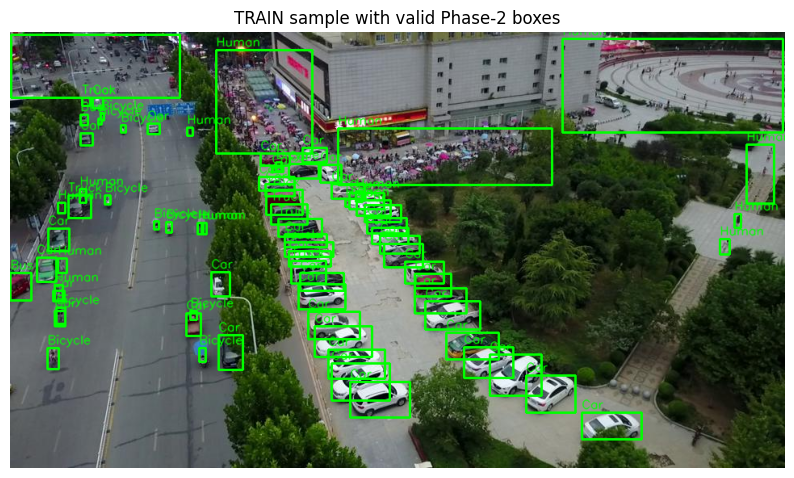

In [4]:
# ============================================================
# Cell 4: Inspect One VisDrone Annotation + Visualize Boxes
# (Robust to ignored / unknown classes)
# ============================================================

INSPECT_SPLIT = "train"

images_dir = VISDRONE_ROOT / INSPECT_SPLIT / "images"
ann_dir = VISDRONE_ROOT / INSPECT_SPLIT / "annotations"

sample_ann_file = sorted(ann_dir.glob("*.txt"))[0]
sample_image_file = images_dir / (sample_ann_file.stem + ".jpg")

print(f"Inspecting annotation: {sample_ann_file.name}")
print(f"Corresponding image  : {sample_image_file.name}")

# ---- Load image ----
img = cv2.imread(str(sample_image_file))
img_vis = img.copy()

h_img, w_img, _ = img.shape
print(f"Image size: {w_img} x {h_img}")

# ---- Parse annotation file ----
with open(sample_ann_file, "r") as f:
    lines = [l.strip() for l in f.readlines() if l.strip()]

print(f"Total annotated rows: {len(lines)}\n")

drawn = 0
skipped = 0

for idx, line in enumerate(lines):
    parts = list(map(int, line.split(",")))
    x, y, w, h, score, vd_cls, occ, trunc = parts

    # ---- Skip ignored / unknown classes ----
    if vd_cls not in VISDRONE_TO_PHASE2:
        skipped += 1
        continue

    phase2_cls = VISDRONE_TO_PHASE2[vd_cls]
    cls_name = PHASE2_CLASSES[phase2_cls]

    print(
        f"Obj {idx:02d}: "
        f"VisDrone class={vd_cls} ({VISDRONE_CLASSES.get(vd_cls, 'UNKNOWN')}), "
        f"Phase2={phase2_cls} ({cls_name}), "
        f"Box=(x={x}, y={y}, w={w}, h={h})"
    )

    cv2.rectangle(
        img_vis,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        img_vis,
        cls_name,
        (x, max(0, y - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    drawn += 1

print(f"\nDrawn objects  : {drawn}")
print(f"Skipped objects: {skipped}")

# ---- Display image ----
img_vis = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_vis)
plt.axis("off")
plt.title(f"{INSPECT_SPLIT.upper()} sample with valid Phase-2 boxes")
plt.show()

In [12]:
# ============================================================
# Cell 5: COCO Schema + Preprocessing Contract
# ============================================================

# ---- COCO category definition (Phase 2) ----
COCO_CATEGORIES = [
    {
        "id": class_id,
        "name": class_name,
        "supercategory": "object"
    }
    for class_id, class_name in PHASE2_CLASSES.items()
]

print("=== COCO Categories (Phase 2) ===")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")
print("================================\n")

# ---- Target input resolution for RF-DETR Nano ----
TARGET_IMAGE_SIZE = 384  # 384x384 (locked for Phase 2)

print(f"Target model input resolution: {TARGET_IMAGE_SIZE} x {TARGET_IMAGE_SIZE}\n")

# ---- Preprocessing policy (LOCKED) ----
PREPROCESSING_POLICY = {
    "resize": {
        "enabled": True,
        "method": "resize_longest_side_then_pad",
        "target_size": TARGET_IMAGE_SIZE,
        "preserve_aspect_ratio": True,
        "pad_value": 0,
    },
    "box_handling": {
        "scale_boxes": True,
        "clip_boxes": True,
        "min_box_area_px": 4,   # discard extremely tiny boxes after resize
    },
    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    }
}

# normalization reference: https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2

print("=== Preprocessing Policy ===")
for k, v in PREPROCESSING_POLICY.items():
    print(f"{k}: {v}")
print("============================")

=== COCO Categories (Phase 2) ===
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Motorcycle

Target model input resolution: 384 x 384

=== Preprocessing Policy ===
resize: {'enabled': True, 'method': 'resize_longest_side_then_pad', 'target_size': 384, 'preserve_aspect_ratio': True, 'pad_value': 0}
box_handling: {'scale_boxes': True, 'clip_boxes': True, 'min_box_area_px': 4}
normalization: {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}


In [13]:
# ============================================================
# Cell 6: Convert VisDrone → COCO (Phase 2)
# ============================================================

def convert_visdrone_split_to_coco(split_name, output_json_path):
    """
    Convert one VisDrone split (train / val / test-dev) to COCO format.
    """
    images_dir = VISDRONE_ROOT / split_name / "images"
    ann_dir = VISDRONE_ROOT / split_name / "annotations"

    coco = {
        "info": {
            "description": f"VisDrone2019-DET {split_name} converted to COCO (Phase 2)",
            "version": "1.0",
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": COCO_CATEGORIES,
    }

    annotation_id = 1
    image_id = 1

    image_files = sorted(images_dir.glob("*.jpg"))

    print(f"\nConverting split: {split_name}")
    print(f"Images found: {len(image_files)}")

    for img_file in tqdm(image_files):
        # ---- Load image to get size ----
        img = Image.open(img_file)
        width, height = img.size

        coco["images"].append({
            "id": image_id,
            "file_name": img_file.name,
            "width": width,
            "height": height,
        })

        ann_file = ann_dir / (img_file.stem + ".txt")
        if not ann_file.exists():
            image_id += 1
            continue

        with open(ann_file, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        for line in lines:
            # ---- Robust parsing (VisDrone annotations can be messy) ----
            parts = [p.strip() for p in line.split(",") if p.strip() != ""]

            # Expect exactly 8 fields
            if len(parts) != 8:
                continue

            try:
                x, y, w, h, score, vd_cls, occ, trunc = map(int, parts)
            except ValueError:
                # Skip malformed rows safely
                continue

            # ---- Skip ignored / unknown classes ----
            if vd_cls not in VISDRONE_TO_PHASE2:
                continue

            # ---- Sanity check box ----
            if w <= 0 or h <= 0:
                continue

            phase2_cls = VISDRONE_TO_PHASE2[vd_cls]

            coco["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": phase2_cls,
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0,
            })

            annotation_id += 1

        image_id += 1

    print(
        f"Finished {split_name}: "
        f"{len(coco['images'])} images, "
        f"{len(coco['annotations'])} annotations"
    )

    with open(output_json_path, "w") as f:
        json.dump(coco, f)

    print(f"Saved COCO annotations to: {output_json_path}")


# ============================================================
# Run conversion for all splits
# ============================================================

COCO_OUTPUT_DIR = PHASE2_ROOT / "coco_annotations"
COCO_OUTPUT_DIR.mkdir(exist_ok=True)

convert_visdrone_split_to_coco(
    split_name="train",
    output_json_path=COCO_OUTPUT_DIR / "visdrone_train_coco.json"
)

convert_visdrone_split_to_coco(
    split_name="val",
    output_json_path=COCO_OUTPUT_DIR / "visdrone_val_coco.json"
)

convert_visdrone_split_to_coco(
    split_name="test-dev",
    output_json_path=COCO_OUTPUT_DIR / "visdrone_testdev_coco.json"
)


Converting split: train
Images found: 6471


100%|███████████████████████████████████████████████████████████████| 6471/6471 [00:18<00:00, 350.29it/s]


Finished train: 6471 images, 322368 annotations
Saved COCO annotations to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\coco_annotations\visdrone_train_coco.json

Converting split: val
Images found: 548


100%|█████████████████████████████████████████████████████████████████| 548/548 [00:01<00:00, 503.45it/s]


Finished val: 548 images, 35251 annotations
Saved COCO annotations to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\coco_annotations\visdrone_val_coco.json

Converting split: test-dev
Images found: 1610


100%|███████████████████████████████████████████████████████████████| 1610/1610 [00:03<00:00, 459.92it/s]


Finished test-dev: 1610 images, 71437 annotations
Saved COCO annotations to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\coco_annotations\visdrone_testdev_coco.json


Loading COCO annotations from:
C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\coco_annotations\visdrone_train_coco.json

loading annotations into memory...
Done (t=1.72s)
creating index...
index created!
=== COCO Categories ===
id=1 | name=Human
id=2 | name=Bicycle
id=3 | name=Car
id=4 | name=Truck
id=5 | name=Bus
id=6 | name=Motorcycle

=== Dataset Statistics ===
Images     : 6471
Annotations: 322368

=== Per-Class Annotation Counts ===
Human       : 88148
Bicycle     : 27059
Car         : 160158
Truck       : 37831
Bus         : 3246
Motorcycle  : 5926



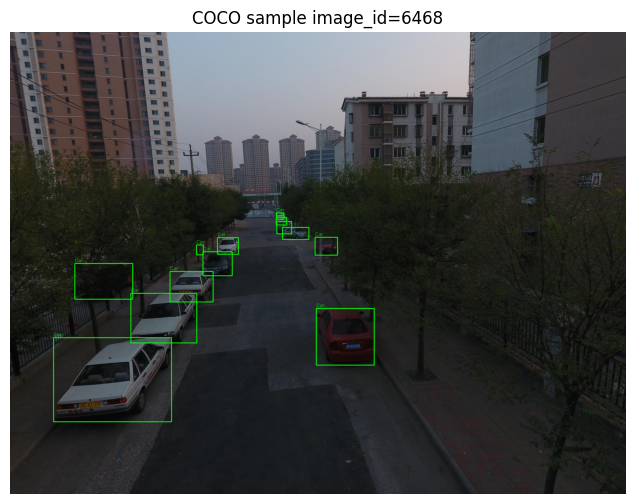

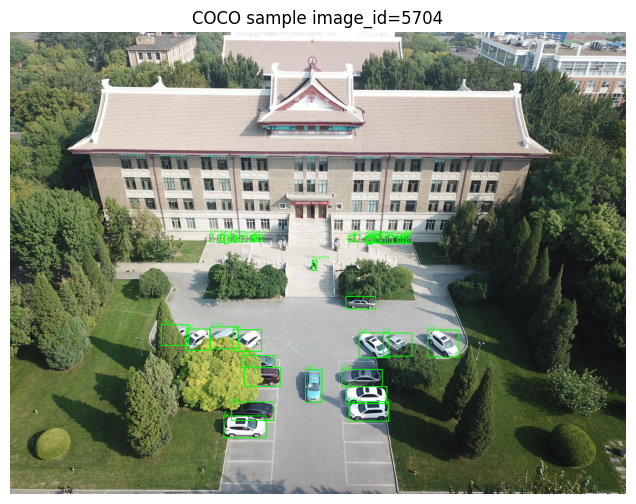

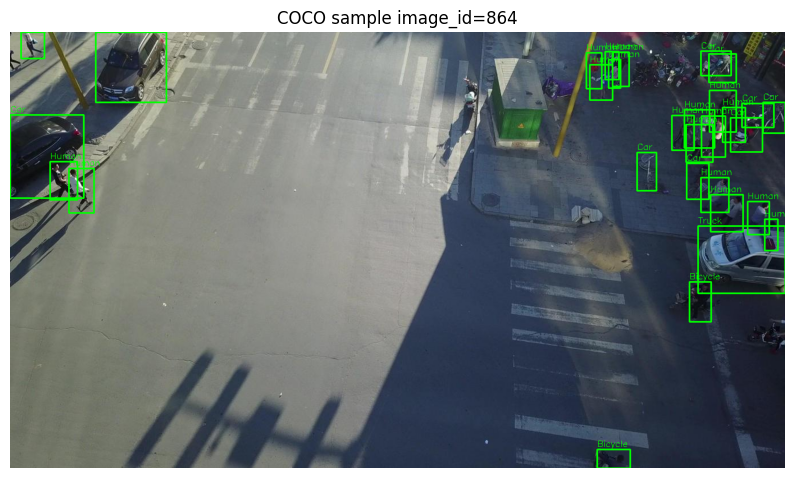

In [14]:
# ============================================================
# Cell 7: Validate COCO Output + Visual Sanity Check
# ============================================================

# ---- Select which split to validate ----
COCO_JSON_PATH = COCO_OUTPUT_DIR / "visdrone_train_coco.json"
IMAGES_DIR = VISDRONE_ROOT / "train" / "images"

print(f"Loading COCO annotations from:\n{COCO_JSON_PATH}\n")

coco = COCO(COCO_JSON_PATH)

# ---- Verify categories ----
print("=== COCO Categories ===")
cats = coco.loadCats(coco.getCatIds())
for c in cats:
    print(f"id={c['id']} | name={c['name']}")
print("=======================\n")

# ---- Dataset statistics ----
num_images = len(coco.getImgIds())
num_annotations = len(coco.getAnnIds())

print("=== Dataset Statistics ===")
print(f"Images     : {num_images}")
print(f"Annotations: {num_annotations}")
print("==========================\n")

# ---- Per-class annotation counts ----
print("=== Per-Class Annotation Counts ===")
for c in cats:
    cat_id = c["id"]
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    print(f"{c['name']:<12}: {len(ann_ids)}")
print("==================================\n")

# ---- Visualize random samples ----
NUM_SAMPLES = 3
sample_img_ids = random.sample(coco.getImgIds(), NUM_SAMPLES)

for img_id in sample_img_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = IMAGES_DIR / img_info["file_name"]

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        x, y, w, h = map(int, ann["bbox"])
        cls_name = PHASE2_CLASSES[ann["category_id"]]

        cv2.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )
        cv2.putText(
            img,
            cls_name,
            (x, max(0, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"COCO sample image_id={img_id}")
    plt.show()

In [20]:
# ============================================================
# Cell 8: Create COCO-Compatible Dataset Shim for RF-DETR
# ============================================================

import shutil
from pathlib import Path

print("\n=== Creating RF-DETR COCO dataset shim ===\n")

# ---- Paths ----
PHASE2_ROOT = Path(r"C:\Users\apraka01\projects\object-identification-uav-camera\phase-2")
VISDRONE_ROOT = PHASE2_ROOT / "visdrone-dataset"
RFDETR_ROOT = PHASE2_ROOT / "rfdetr"

COCO_ANN_SRC = RFDETR_ROOT / "coco_annotations"

# ---- COCO expected structure ----
COCO_TRAIN_IMG = RFDETR_ROOT / "train2017"
COCO_VAL_IMG   = RFDETR_ROOT / "val2017"
COCO_ANN_DIR   = RFDETR_ROOT / "annotations"

COCO_TRAIN_ANN = COCO_ANN_DIR / "instances_train2017.json"
COCO_VAL_ANN   = COCO_ANN_DIR / "instances_val2017.json"

# ---- Create directories ----
for d in [COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_ANN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Copy images (only if directory empty) ----
def copy_images_if_needed(src_dir, dst_dir, split_name):
    if any(dst_dir.iterdir()):
        print(f"[SKIP] {split_name} images already exist ({dst_dir})")
        return
    
    src_images = sorted(src_dir.glob("*.jpg"))
    print(f"[COPY] {split_name}: {len(src_images)} images")
    
    for img in src_images:
        shutil.copy2(img, dst_dir / img.name)

copy_images_if_needed(
    VISDRONE_ROOT / "train" / "images",
    COCO_TRAIN_IMG,
    "TRAIN"
)

copy_images_if_needed(
    VISDRONE_ROOT / "val" / "images",
    COCO_VAL_IMG,
    "VAL"
)

# ---- Copy & rename annotation files ----
def copy_annotation(src, dst, name):
    if dst.exists():
        print(f"[SKIP] {name} annotation already exists")
    else:
        shutil.copy2(src, dst)
        print(f"[COPY] {name} annotation")

copy_annotation(
    COCO_ANN_SRC / "visdrone_train_coco.json",
    COCO_TRAIN_ANN,
    "TRAIN"
)

copy_annotation(
    COCO_ANN_SRC / "visdrone_val_coco.json",
    COCO_VAL_ANN,
    "VAL"
)

print("\n=== COCO shim ready ===")
print(f"Images  : {RFDETR_ROOT / 'train2017'}")
print(f"Images  : {RFDETR_ROOT / 'val2017'}")
print(f"Annots  : {RFDETR_ROOT / 'annotations'}")


=== Creating RF-DETR COCO dataset shim ===

[COPY] TRAIN: 6471 images
[COPY] VAL: 548 images
[COPY] TRAIN annotation
[COPY] VAL annotation

=== COCO shim ready ===
Images  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\train2017
Images  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\val2017
Annots  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-2\rfdetr\annotations


In [27]:
# ============================================================
# CPU Sanity Check — Forward ONLY (No Backward, No Training)
# ============================================================

import torch
from rfdetr import RFDETRNano
from rfdetr.datasets.coco import build as build_coco
from types import SimpleNamespace

print("\nRunning CPU forward-only sanity check...\n")

# ---- Initialize RF-DETR Nano ----
model = RFDETRNano(num_classes=NUM_CLASSES)

# IMPORTANT: switch the *actual* torch model to eval mode
torch_model = model.model.model
torch_model.eval()

# ---- Minimal args object required by build_coco ----
args = SimpleNamespace(
    dataset_file="coco",
    coco_path=str(PHASE2_ROOT / "rfdetr"),
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    patch_size=16,
    num_windows=2,
)

# ---- Build dataset (RF-DETR handles transforms internally) ----
dataset = build_coco(
    image_set="train",
    args=args,
    resolution=384
)

print(f"Dataset length: {len(dataset)}")

# ---- Fetch one sample ----
samples, targets = dataset[0]

# Batchify
samples = samples.unsqueeze(0)
targets = [{k: v for k, v in targets.items()}]

# ---- Forward pass ONLY ----
with torch.no_grad():
    outputs = torch_model(samples, targets)

print("Forward pass successful")
print("Output keys:", outputs.keys())


Running CPU forward-only sanity check...

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
loading annotations into memory...
Done (t=1.60s)
creating index...
index created!
Dataset length: 6471
Forward pass successful
Output keys: dict_keys(['pred_logits', 'pred_boxes', 'aux_outputs', 'enc_outputs'])
